## DATA LOADER

In [4]:
from pathlib import Path
import pandas as pd
import numpy as np

DATA_DIR = Path("data")

# 라벨 & 메타
train_labels = pd.read_csv(DATA_DIR / "train/train_labels.csv", encoding="utf-8-sig")
info = pd.read_excel(DATA_DIR / "info.xlsx", header=3)

# 기상 예보
ldaps_train = pd.read_csv(DATA_DIR / "train/ldaps_train.csv", encoding="utf-8-sig")
gfs_train = pd.read_csv(DATA_DIR / "train/gfs_train.csv", encoding="utf-8-sig")

# SCADA (참고용)
scada_vestas = pd.read_csv(DATA_DIR / "train/scada_vestas_train.csv", encoding="utf-8-sig")
scada_unison = pd.read_csv(DATA_DIR / "train/scada_unison_train.csv", encoding="utf-8-sig")

# 시간 변환
train_labels["kst_dtm"] = pd.to_datetime(train_labels["kst_dtm"])
ldaps_train["forecast_kst_dtm"] = pd.to_datetime(ldaps_train["forecast_kst_dtm"])
gfs_train["forecast_kst_dtm"] = pd.to_datetime(gfs_train["forecast_kst_dtm"])

print("labels:", train_labels.shape)
print("ldaps:", ldaps_train.shape, "| gfs:", gfs_train.shape)
print("scada_vestas:", scada_vestas.shape, "| scada_unison:", scada_unison.shape)

labels: (26304, 4)
ldaps: (420864, 35) | gfs: (236736, 40)
scada_vestas: (157819, 37) | scada_unison: (105264, 16)


Fontconfig warning: ignoring UTF-8: not a valid region tag
Matplotlib is building the font cache; this may take a moment.


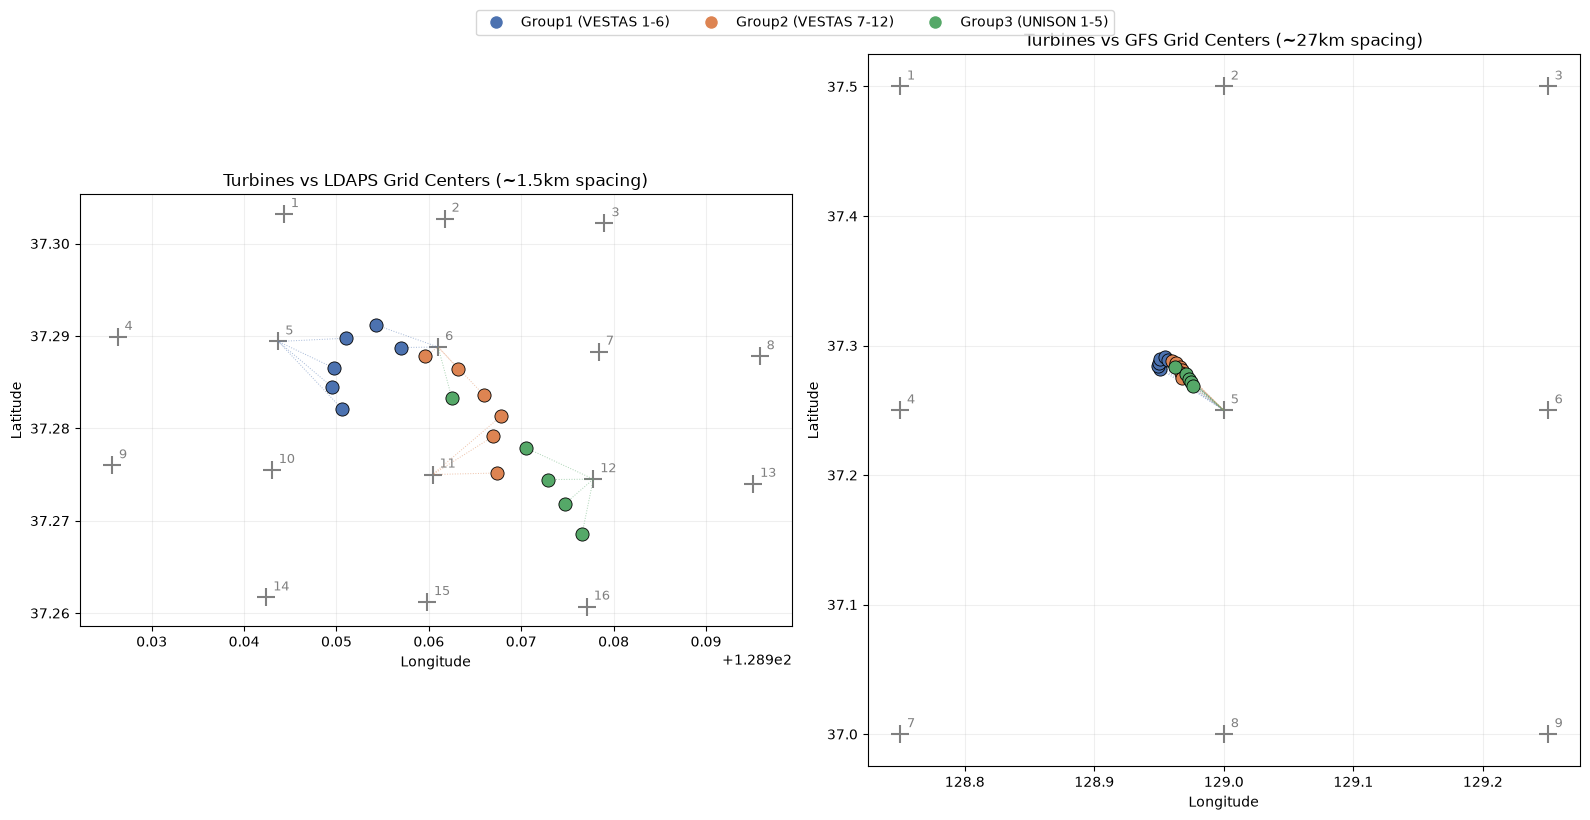

In [1]:
# 격자 / 터빈 위치 확인

import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

# 1. 터빈 좌표 파싱 (info.xlsx)
def dms_to_dd(s):
    m = re.match(r"(\d+)°(\d+)'([\d.]+)\"([NSEW])", s)
    d, mi, se, dirc = m.groups()
    dd = float(d) + float(mi) / 60 + float(se) / 3600
    if dirc in ['S', 'W']:
        dd = -dd
    return dd

info = pd.read_excel('data/info.xlsx', header=3)
lats, lons = [], []
for c in info['좌표(Google)']:
    lat_s, lon_s = c.split()
    lats.append(dms_to_dd(lat_s))
    lons.append(dms_to_dd(lon_s))
info['lat'] = lats
info['lon'] = lons
info['group'] = info['KPX그룹'].ffill().astype(int)
turbines = info[['호기', '제작사', 'group', 'lat', 'lon']].copy()

# 2. 격자 좌표 로드
ldaps_grids = pd.read_csv('data/train/ldaps_train.csv', usecols=['grid_id', 'latitude', 'longitude']).drop_duplicates()
gfs_grids = pd.read_csv('data/train/gfs_train.csv', usecols=['grid_id', 'latitude', 'longitude']).drop_duplicates()

# 3. 최근접 격자 계산
def nearest_grid(lat, lon, grids):
    d = np.sqrt((grids.latitude - lat)**2 + (grids.longitude - lon)**2)
    idx = d.idxmin()
    return int(grids.loc[idx, 'grid_id']), d[idx]

turbines[['ldaps_grid', 'ldaps_dist']] = turbines.apply(
    lambda t: pd.Series(nearest_grid(t.lat, t.lon, ldaps_grids)), axis=1)
turbines[['gfs_grid', 'gfs_dist']] = turbines.apply(
    lambda t: pd.Series(nearest_grid(t.lat, t.lon, gfs_grids)), axis=1)

# 4. 시각화 (격자는 점(+)으로만 표시, 경계 사각형은 그리지 않음)
group_colors = {1: '#4C72B0', 2: '#DD8452', 3: '#55A868'}
group_labels = {1: 'Group1 (VESTAS 1-6)', 2: 'Group2 (VESTAS 7-12)', 3: 'Group3 (UNISON 1-5)'}

def draw_panel(ax, grids, grid_col, marker_size, title):
    ax.scatter(grids.longitude, grids.latitude, marker='+', s=marker_size,
               color='gray', linewidths=1.5, zorder=2, label='Grid center')
    for _, g in grids.iterrows():
        ax.annotate(int(g.grid_id), (g.longitude, g.latitude), fontsize=9,
                    color='gray', xytext=(5, 5), textcoords='offset points')

    for _, t in turbines.iterrows():
        c = group_colors[t.group]
        ax.scatter(t.lon, t.lat, s=90, color=c, edgecolors='black', linewidths=0.6, zorder=5)
        grid_row = grids[grids.grid_id == t[grid_col]].iloc[0]
        ax.plot([t.lon, grid_row.longitude], [t.lat, grid_row.latitude],
                 color=c, linewidth=0.7, alpha=0.5, linestyle=':')

    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.set_title(title)
    ax.grid(alpha=0.2)
    ax.set_aspect('equal')

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
draw_panel(axes[0], ldaps_grids, 'ldaps_grid', 150, 'Turbines vs LDAPS Grid Centers (~1.5km spacing)')
draw_panel(axes[1], gfs_grids, 'gfs_grid', 150, 'Turbines vs GFS Grid Centers (~27km spacing)')

handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=c, markersize=10, label=group_labels[g])
           for g, c in group_colors.items()]
fig.legend(handles=handles, loc='upper center', ncol=3, bbox_to_anchor=(0.5, 1.02), fontsize=10)

plt.tight_layout()
plt.savefig('turbine_grid_clean.png', dpi=140, bbox_inches='tight')
plt.show()

=== train_labels missing value report ===
             missing_count  missing_pct
kpx_group_3           8766        33.33
kpx_group_1            104         0.40
kpx_group_2            103         0.39

=== ldaps_train missing value report ===
No missing values

=== gfs_train missing value report ===
No missing values

=== Monthly missing count (train_labels) ===

kpx_group_1 missing timestamps by month:
kst_dtm
2022-03     2
2022-07    11
2022-10    82
2023-07     3
2024-07     6
Freq: M, Name: count, dtype: int64

kpx_group_2 missing timestamps by month:
kst_dtm
2022-03     2
2022-07    11
2022-10    82
2023-07     2
2024-07     6
Freq: M, Name: count, dtype: int64

kpx_group_3 missing timestamps by month:
kst_dtm
2022-01    743
2022-02    672
2022-03    744
2022-04    720
2022-05    744
2022-06    720
2022-07    744
2022-08    744
2022-09    720
2022-10    744
2022-11    720
2022-12    744
2023-01      1
2024-07      6
Freq: M, Name: count, dtype: int64


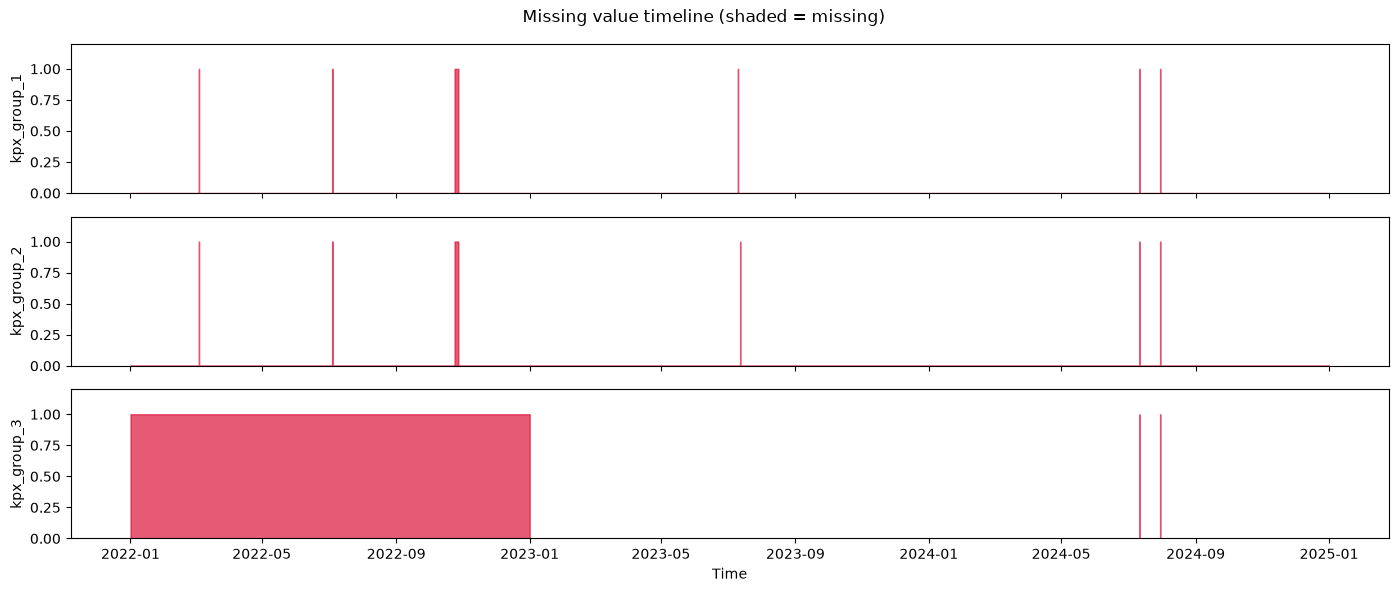


=== LDAPS missing count per grid_id ===
grid_id
1     0
2     0
3     0
4     0
5     0
6     0
7     0
8     0
9     0
10    0
11    0
12    0
13    0
14    0
15    0
16    0
dtype: int64

=== GFS missing count per grid_id ===
grid_id
1    0
2    0
3    0
4    0
5    0
6    0
7    0
8    0
9    0
dtype: int64


In [3]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 0. Load data
# ============================================================
DATA_DIR = Path("data")

train_labels = pd.read_csv(DATA_DIR / "train/train_labels.csv", encoding="utf-8-sig")
ldaps_train = pd.read_csv(DATA_DIR / "train/ldaps_train.csv", encoding="utf-8-sig")
gfs_train = pd.read_csv(DATA_DIR / "train/gfs_train.csv", encoding="utf-8-sig")

train_labels["kst_dtm"] = pd.to_datetime(train_labels["kst_dtm"])
ldaps_train["forecast_kst_dtm"] = pd.to_datetime(ldaps_train["forecast_kst_dtm"])
gfs_train["forecast_kst_dtm"] = pd.to_datetime(gfs_train["forecast_kst_dtm"])

# ============================================================
# 1. Missing value count/ratio per column
# ============================================================
def missing_report(df, name):
    miss = df.isna().sum()
    miss_pct = (miss / len(df) * 100).round(2)
    report = pd.DataFrame({'missing_count': miss, 'missing_pct': miss_pct})
    report = report[report['missing_count'] > 0].sort_values('missing_pct', ascending=False)
    print(f"=== {name} missing value report ===")
    print(report if len(report) > 0 else "No missing values")
    print()
    return report

missing_report(train_labels, 'train_labels')
missing_report(ldaps_train, 'ldaps_train')
missing_report(gfs_train, 'gfs_train')

# ============================================================
# 2. Check if train_labels missingness is concentrated in time (monthly)
# ============================================================
print("=== Monthly missing count (train_labels) ===")
for col in ['kpx_group_1', 'kpx_group_2', 'kpx_group_3']:
    missing_dates = train_labels[train_labels[col].isna()]['kst_dtm']
    print(f"\n{col} missing timestamps by month:")
    print(missing_dates.dt.to_period('M').value_counts().sort_index())

# ============================================================
# 3. Visualize missing timeline
# ============================================================
fig, axes = plt.subplots(3, 1, figsize=(14, 6), sharex=True)
for ax, col in zip(axes, ['kpx_group_1', 'kpx_group_2', 'kpx_group_3']):
    is_missing = train_labels[col].isna().astype(int)
    ax.fill_between(train_labels['kst_dtm'], is_missing, step='mid', alpha=0.7, color='crimson')
    ax.set_ylabel(col)
    ax.set_ylim(0, 1.2)
axes[-1].set_xlabel('Time')
plt.suptitle('Missing value timeline (shaded = missing)')
plt.tight_layout()
plt.show()

# ============================================================
# 4. Check missing counts per grid_id (LDAPS/GFS)
# ============================================================
print("\n=== LDAPS missing count per grid_id ===")
print(ldaps_train.groupby('grid_id').apply(lambda d: d.isna().sum().sum()))

print("\n=== GFS missing count per grid_id ===")
print(gfs_train.groupby('grid_id').apply(lambda d: d.isna().sum().sum()))

In [4]:
from pathlib import Path
import pandas as pd

DATA_DIR = Path("data")
train_labels = pd.read_csv(DATA_DIR / "train/train_labels.csv", encoding="utf-8-sig")
train_labels["kst_dtm"] = pd.to_datetime(train_labels["kst_dtm"])

# ============================================================
# 1. group1, group2: 전체 기간 기준 실제 결측 시점 확인
# ============================================================
print("=== kpx_group_1 missing rows ===")
g1_missing = train_labels[train_labels['kpx_group_1'].isna()]
print(g1_missing[['kst_dtm', 'kpx_group_1', 'kpx_group_2', 'kpx_group_3']])
print(f"total: {len(g1_missing)} rows\n")

print("=== kpx_group_2 missing rows ===")
g2_missing = train_labels[train_labels['kpx_group_2'].isna()]
print(g2_missing[['kst_dtm', 'kpx_group_1', 'kpx_group_2', 'kpx_group_3']])
print(f"total: {len(g2_missing)} rows\n")

# ============================================================
# 2. group1, group2 결측이 같은 시점에 겹치는지 확인
# ============================================================
overlap = pd.merge(g1_missing[['kst_dtm']], g2_missing[['kst_dtm']], on='kst_dtm', how='inner')
print(f"=== group1 & group2 결측 겹치는 시점: {len(overlap)}개 ===")
print(overlap)
print()

# ============================================================
# 3. group3: 구조적 결측(2022년) 제외하고, 실제 가동기간(2023~2024) 내 결측만 확인
# ============================================================
g3_valid_period = train_labels[train_labels['kst_dtm'] >= '2023-01-01']
g3_missing_real = g3_valid_period[g3_valid_period['kpx_group_3'].isna()]

print("=== kpx_group_3 missing rows (2022년 구조적 결측 제외, 2023년 이후만) ===")
print(g3_missing_real[['kst_dtm', 'kpx_group_1', 'kpx_group_2', 'kpx_group_3']])
print(f"total: {len(g3_missing_real)} rows")

=== kpx_group_1 missing rows ===
                  kst_dtm  kpx_group_1  kpx_group_2  kpx_group_3
1501  2022-03-04 14:00:00          NaN          NaN          NaN
1502  2022-03-04 15:00:00          NaN          NaN          NaN
4424  2022-07-04 09:00:00          NaN          NaN          NaN
4425  2022-07-04 10:00:00          NaN          NaN          NaN
4426  2022-07-04 11:00:00          NaN          NaN          NaN
...                   ...          ...          ...          ...
22140 2024-07-11 13:00:00          NaN          NaN          NaN
22141 2024-07-11 14:00:00          NaN          NaN          NaN
22595 2024-07-30 12:00:00          NaN          NaN          NaN
22596 2024-07-30 13:00:00          NaN          NaN          NaN
22597 2024-07-30 14:00:00          NaN          NaN          NaN

[104 rows x 4 columns]
total: 104 rows

=== kpx_group_2 missing rows ===
                  kst_dtm  kpx_group_1  kpx_group_2  kpx_group_3
1501  2022-03-04 14:00:00          NaN          

10m / 100m: 순간값 기준 Bias/MAE (기존과 동일해야 정상)
[kpx_group_1] ldaps_ws10   Bias: -1.947  MAE: 2.241
[kpx_group_1] gfs_ws100    Bias: -2.816  MAE: 3.159

[kpx_group_2] ldaps_ws10   Bias: -2.115  MAE: 2.420
[kpx_group_2] gfs_ws100    Bias: -3.236  MAE: 3.515

[kpx_group_3] ldaps_ws10   Bias: -0.830  MAE: 1.627
[kpx_group_3] gfs_ws100    Bias: -1.953  MAE: 2.468

50m max / min: 각각의 Bias (참고용 - max는 양수, min은 음수가 정상)
[kpx_group_1] ldaps_ws50_max   Bias: +0.714
[kpx_group_1] ldaps_ws50_min   Bias: +0.195

[kpx_group_2] ldaps_ws50_max   Bias: +0.722
[kpx_group_2] ldaps_ws50_min   Bias: +0.194

[kpx_group_3] ldaps_ws50_max   Bias: +1.962
[kpx_group_3] ldaps_ws50_min   Bias: +1.447

SCADA 실측값이 LDAPS 50m [min, max] 범위 안에 포함되는 비율
[kpx_group_1] 범위 내 포함 비율: 12.1%  (n=26304)
[kpx_group_2] 범위 내 포함 비율: 11.9%  (n=26304)
[kpx_group_3] 범위 내 포함 비율: 10.5%  (n=17537)

월별 Bias/MAE (10m, 100m)
--- kpx_group_1 ---
       ldaps10_bias  ldaps10_mae  gfs100_bias  gfs100_mae
month                                        

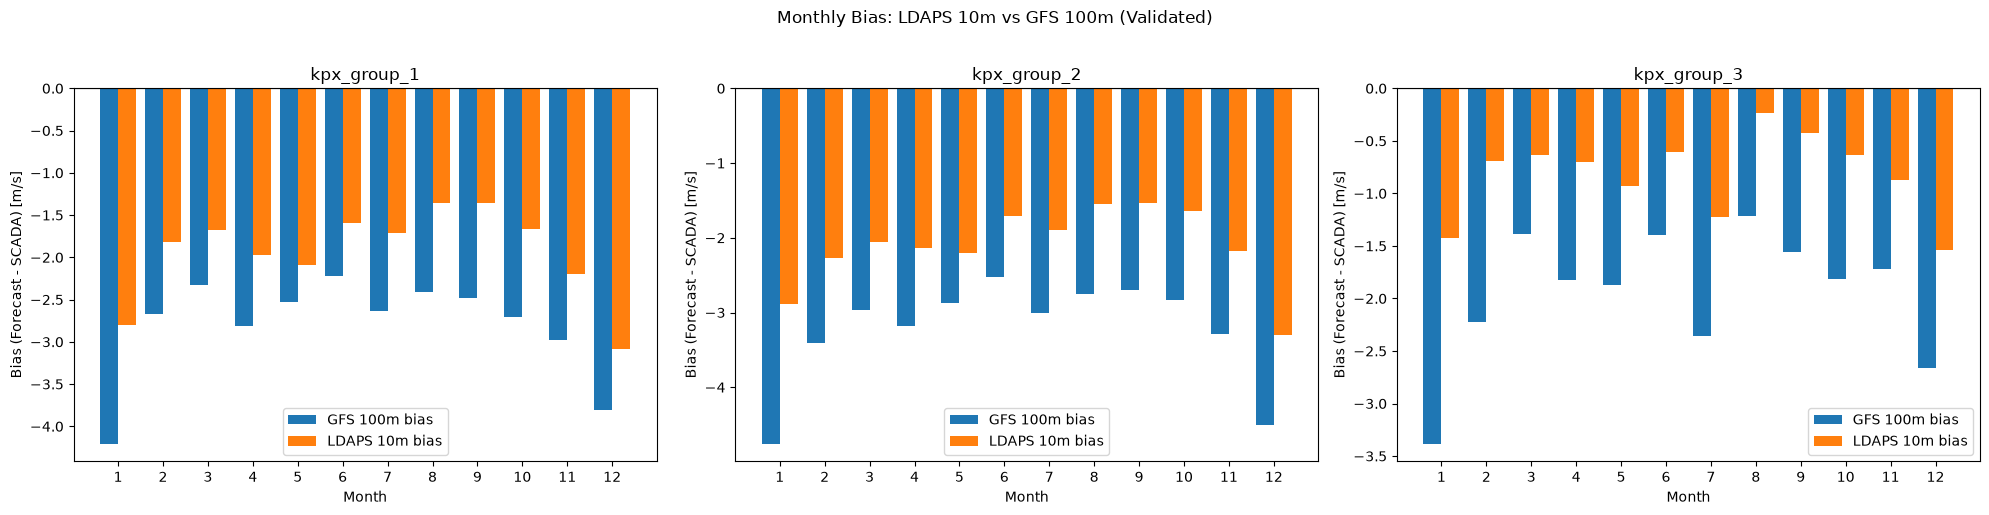

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

DATA_DIR = Path("data")

# ============================================================
# 0. 데이터 로드
# ============================================================
ldaps_train = pd.read_csv(DATA_DIR / "train/ldaps_train.csv", encoding="utf-8-sig")
gfs_train = pd.read_csv(DATA_DIR / "train/gfs_train.csv", encoding="utf-8-sig")
scada_vestas = pd.read_csv(DATA_DIR / "train/scada_vestas_train.csv", encoding="utf-8-sig")
scada_unison = pd.read_csv(DATA_DIR / "train/scada_unison_train.csv", encoding="utf-8-sig")
info = pd.read_excel(DATA_DIR / "info.xlsx", header=3)

ldaps_train["forecast_kst_dtm"] = pd.to_datetime(ldaps_train["forecast_kst_dtm"])
gfs_train["forecast_kst_dtm"] = pd.to_datetime(gfs_train["forecast_kst_dtm"])
scada_vestas["kst_dtm"] = pd.to_datetime(scada_vestas["kst_dtm"])
scada_unison["kst_dtm"] = pd.to_datetime(scada_unison["kst_dtm"])

# ============================================================
# 1. 풍속 계산
#    - LDAPS 10m: 순간값 그대로 사용 (그대로 유효)
#    - LDAPS 50m: max, min 각각 따로 계산 (평균 내지 않음)
#    - GFS 100m: 순간값 그대로 사용 (그대로 유효)
# ============================================================
ldaps_train['ws10'] = np.sqrt(ldaps_train['heightAboveGround_10_10u']**2 + ldaps_train['heightAboveGround_10_10v']**2)
ldaps_train['ws50_max'] = np.sqrt(ldaps_train['heightAboveGround_50_50MUmax']**2 + ldaps_train['heightAboveGround_50_50MVmax']**2)
ldaps_train['ws50_min'] = np.sqrt(ldaps_train['heightAboveGround_50_50MUmin']**2 + ldaps_train['heightAboveGround_50_50MVmin']**2)
ldaps_train['ws50_range'] = ldaps_train['ws50_max'] - ldaps_train['ws50_min']

gfs_train['ws100'] = np.sqrt(gfs_train['heightAboveGround_100_100u']**2 + gfs_train['heightAboveGround_100_100v']**2)

ldaps_pivot10 = ldaps_train.pivot(index='forecast_kst_dtm', columns='grid_id', values='ws10')
ldaps_pivot50max = ldaps_train.pivot(index='forecast_kst_dtm', columns='grid_id', values='ws50_max')
ldaps_pivot50min = ldaps_train.pivot(index='forecast_kst_dtm', columns='grid_id', values='ws50_min')
gfs_pivot100 = gfs_train.pivot(index='forecast_kst_dtm', columns='grid_id', values='ws100')

GROUP_LDAPS_GRIDS = {
    'kpx_group_1': list(range(1, 17)),
    'kpx_group_2': [6, 7, 11, 12],
    'kpx_group_3': [6, 7, 11, 12],
}
GFS_GRID = 5

rep_ws = {}
for g, grids in GROUP_LDAPS_GRIDS.items():
    rep_ws[g] = pd.DataFrame({
        'ldaps_ws10': ldaps_pivot10[grids].mean(axis=1),
        'ldaps_ws50_max': ldaps_pivot50max[grids].mean(axis=1),
        'ldaps_ws50_min': ldaps_pivot50min[grids].mean(axis=1),
        'gfs_ws100': gfs_pivot100[GFS_GRID],
    })

# ============================================================
# 2. SCADA 그룹 집계
# ============================================================
info['group'] = info['KPX그룹'].ffill().astype(int)
vestas_group_map = info[info['제작사'] == 'VESTAS'].set_index('호기')['group'].to_dict()
unison_turbines = info[info['제작사'] == 'UNISON']['호기'].tolist()

def scada_group_avg_ws(scada_df, prefix, turbine_ids):
    ws_cols = [f'{prefix}_wtg{int(t):02d}_ws' for t in turbine_ids]
    ws_cols = [c for c in ws_cols if c in scada_df.columns]
    hourly = scada_df.set_index('kst_dtm')[ws_cols].resample('1h').mean()
    return hourly.mean(axis=1)

scada_by_group = {
    'kpx_group_1': scada_group_avg_ws(scada_vestas, 'vestas', [t for t,g in vestas_group_map.items() if g==1]),
    'kpx_group_2': scada_group_avg_ws(scada_vestas, 'vestas', [t for t,g in vestas_group_map.items() if g==2]),
    'kpx_group_3': scada_group_avg_ws(scada_unison, 'unison', unison_turbines),
}

# ============================================================
# 3. 병합 + 계절/월 컬럼
# ============================================================
def season(m):
    if m in [3,4,5]: return 'Spring'
    if m in [6,7,8]: return 'Summer'
    if m in [9,10,11]: return 'Fall'
    return 'Winter'

comparison = {}
for g in ['kpx_group_1', 'kpx_group_2', 'kpx_group_3']:
    merged = rep_ws[g].copy()
    merged['scada_ws'] = scada_by_group[g]
    merged = merged.dropna()
    merged['month'] = merged.index.month
    merged['season'] = merged['month'].apply(season)
    comparison[g] = merged

# ============================================================
# 4. 10m / 100m Bias-MAE 요약 (기존 검증된 것, 재확인용)
# ============================================================
print("=" * 60)
print("10m / 100m: 순간값 기준 Bias/MAE (기존과 동일해야 정상)")
print("=" * 60)
for g in ['kpx_group_1', 'kpx_group_2', 'kpx_group_3']:
    merged = comparison[g]
    for src in ['ldaps_ws10', 'gfs_ws100']:
        bias = (merged[src] - merged['scada_ws']).mean()
        mae = (merged[src] - merged['scada_ws']).abs().mean()
        print(f'[{g}] {src:12s} Bias: {bias:+.3f}  MAE: {mae:.3f}')
    print()

# ============================================================
# 5. 50m max/min 각각의 Bias 확인 (참고용 - 방향성 검증)
# ============================================================
print("=" * 60)
print("50m max / min: 각각의 Bias (참고용 - max는 양수, min은 음수가 정상)")
print("=" * 60)
for g in ['kpx_group_1', 'kpx_group_2', 'kpx_group_3']:
    merged = comparison[g]
    for src in ['ldaps_ws50_max', 'ldaps_ws50_min']:
        bias = (merged[src] - merged['scada_ws']).mean()
        print(f'[{g}] {src:16s} Bias: {bias:+.3f}')
    print()

# ============================================================
# 6. SCADA 실측값이 LDAPS 50m [min, max] 범위 안에 드는 비율
#    -> 50m max/min이 그 시간대 변동범위를 잘 포착하는지 확인
# ============================================================
print("=" * 60)
print("SCADA 실측값이 LDAPS 50m [min, max] 범위 안에 포함되는 비율")
print("=" * 60)
for g in ['kpx_group_1', 'kpx_group_2', 'kpx_group_3']:
    merged = comparison[g]
    within = (merged['scada_ws'] >= merged['ldaps_ws50_min']) & (merged['scada_ws'] <= merged['ldaps_ws50_max'])
    print(f'[{g}] 범위 내 포함 비율: {within.mean()*100:.1f}%  (n={len(merged)})')

# ============================================================
# 7. 월별 Bias/MAE 테이블 (10m, 100m만 - 신뢰 가능한 변수)
# ============================================================
print()
print("=" * 60)
print("월별 Bias/MAE (10m, 100m)")
print("=" * 60)
for g in ['kpx_group_1', 'kpx_group_2', 'kpx_group_3']:
    merged = comparison[g]
    monthly_stats = merged.groupby('month').apply(
        lambda d: pd.Series({
            'ldaps10_bias': (d['ldaps_ws10']-d['scada_ws']).mean(),
            'ldaps10_mae': (d['ldaps_ws10']-d['scada_ws']).abs().mean(),
            'gfs100_bias': (d['gfs_ws100']-d['scada_ws']).mean(),
            'gfs100_mae': (d['gfs_ws100']-d['scada_ws']).abs().mean(),
        })
    ).reindex(range(1, 13))
    print(f"--- {g} ---")
    print(monthly_stats.round(3))
    print()

# ============================================================
# 8. 시각화: 월별 Bias (10m, 100m) + 50m range 변동성
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(20, 5), sharey=False)

for ax, g in zip(axes, ['kpx_group_1', 'kpx_group_2', 'kpx_group_3']):
    merged = comparison[g]
    bias_by_month = merged.groupby('month').apply(
        lambda d: pd.Series({
            'ldaps10_bias': (d['ldaps_ws10']-d['scada_ws']).mean(),
            'gfs100_bias': (d['gfs_ws100']-d['scada_ws']).mean(),
        })
    ).reindex(range(1, 13))

    x = np.arange(1, 13)
    ax.bar(x - 0.2, bias_by_month['gfs100_bias'], width=0.4, label='GFS 100m bias')
    ax.bar(x + 0.2, bias_by_month['ldaps10_bias'], width=0.4, label='LDAPS 10m bias')
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_xticks(x)
    ax.set_title(g)
    ax.set_xlabel('Month')
    ax.set_ylabel('Bias (Forecast - SCADA) [m/s]')
    ax.legend()

plt.suptitle('Monthly Bias: LDAPS 10m vs GFS 100m (Validated)', y=1.02)
plt.tight_layout()
plt.show()